In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set a simple visual style for plots.
sns.set_theme(style="whitegrid")

In [2]:
PROJECT_ROOT = Path("..")

DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"

print("Project root:", PROJECT_ROOT.resolve())
print("Processed data path:", DATA_PROCESSED.resolve())

Project root: /workspaces/potential-pathway-index
Processed data path: /workspaces/potential-pathway-index/data/processed


In [3]:
early_behavior_dataset_path = DATA_PROCESSED / "early_behavior_dataset.csv"

print("Required input file:")
print(early_behavior_dataset_path)

print("\nFile exists:")
print(early_behavior_dataset_path.exists())

Required input file:
../data/processed/early_behavior_dataset.csv

File exists:
True


In [4]:
early_behavior_dataset = pd.read_csv(early_behavior_dataset_path)

print("early_behavior_dataset loaded successfully.")
print("Shape:", early_behavior_dataset.shape)

early_behavior_dataset.head()

early_behavior_dataset loaded successfully.
Shape: (32593, 39)


,id_student,code_module,code_presentation,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,...,max_score_30d,total_assessment_weight_30d,late_submission_count_30d,avg_days_late_30d,max_days_late_30d,first_submission_day_30d,last_submission_day_30d,banked_submissions_30d,has_assessment_submission_30d,has_assessment_score_30d
0,11391,AAA,2013J,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,...,78.0,10.0,0.0,0.0,0.0,18.0,18.0,0.0,1,1
1,28400,AAA,2013J,F,Scotland,HE Qualification,20-30%,35-55,0,60,...,70.0,10.0,1.0,3.0,3.0,22.0,22.0,0.0,1,1
2,30268,AAA,2013J,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,...,-1.0,0.0,0.0,0.0,0.0,-1.0,-1.0,0.0,0,0
3,31604,AAA,2013J,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,...,72.0,10.0,0.0,0.0,0.0,17.0,17.0,0.0,1,1
4,32885,AAA,2013J,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,...,69.0,10.0,1.0,7.0,7.0,26.0,26.0,0.0,1,1


In [5]:
main_keys = ["id_student", "code_module", "code_presentation"]

total_rows = early_behavior_dataset.shape[0]
unique_keys = early_behavior_dataset[main_keys].drop_duplicates().shape[0]

print("Total rows:", total_rows)
print("Unique student-module-presentation keys:", unique_keys)
print("Is the main key unique?", total_rows == unique_keys)

Total rows: 32593
Unique student-module-presentation keys: 32593
Is the main key unique? True


In [6]:
print("Number of columns:", early_behavior_dataset.shape[1])

early_behavior_dataset.columns.tolist()

Number of columns: 39


['id_student',
 'code_module',
 'code_presentation',
 'gender',
 'region',
 'highest_education',
 'imd_band',
 'age_band',
 'num_of_prev_attempts',
 'studied_credits',
 'disability',
 'date_registration',
 'final_result',
 'at_risk_misalignment',
 'total_clicks_30d',
 'active_days_30d',
 'avg_clicks_per_active_day_30d',
 'max_clicks_single_day_30d',
 'std_clicks_active_day_30d',
 'first_activity_day_30d',
 'last_activity_day_30d',
 'activity_span_30d',
 'days_since_last_activity_30d',
 'has_vle_activity_30d',
 'submitted_assessments_30d',
 'scored_assessments_30d',
 'missing_score_submissions_30d',
 'avg_score_30d',
 'min_score_30d',
 'max_score_30d',
 'total_assessment_weight_30d',
 'late_submission_count_30d',
 'avg_days_late_30d',
 'max_days_late_30d',
 'first_submission_day_30d',
 'last_submission_day_30d',
 'banked_submissions_30d',
 'has_assessment_submission_30d',
 'has_assessment_score_30d']

In [7]:
missing_values = early_behavior_dataset.isnull().sum().sort_values(ascending=False)

missing_values[missing_values > 0]

imd_band             1111
date_registration      45
dtype: int64

In [8]:
target_distribution = early_behavior_dataset["at_risk_misalignment"].value_counts().sort_index()
target_percentage = early_behavior_dataset["at_risk_misalignment"].value_counts(normalize=True).sort_index() * 100

target_summary = pd.DataFrame({
    "count": target_distribution,
    "percentage": target_percentage.round(2)
})

target_summary

,count,percentage
at_risk_misalignment,,
0,15385,47.2
1,17208,52.8


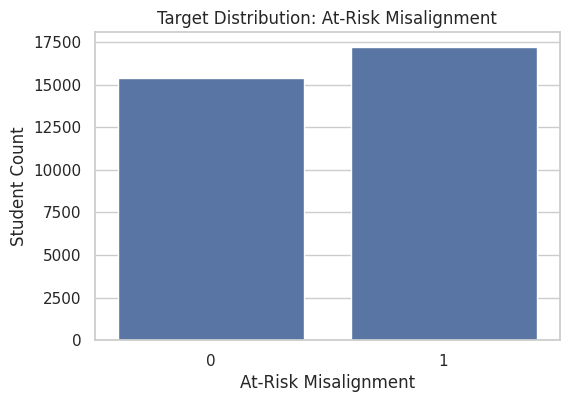

In [9]:
plt.figure(figsize=(6, 4))

sns.countplot(
    data=early_behavior_dataset,
    x="at_risk_misalignment"
)

plt.title("Target Distribution: At-Risk Misalignment")
plt.xlabel("At-Risk Misalignment")
plt.ylabel("Student Count")

plt.show()

In [10]:
behavior_flag_columns = [
    "has_vle_activity_30d",
    "has_assessment_submission_30d",
    "has_assessment_score_30d"
]

print("Behavior availability columns:")
print(behavior_flag_columns)

Behavior availability columns:
['has_vle_activity_30d', 'has_assessment_submission_30d', 'has_assessment_score_30d']


In [11]:
behavior_availability_by_target = (
    early_behavior_dataset
    .groupby("at_risk_misalignment")[behavior_flag_columns]
    .mean()
    .T
)

behavior_availability_by_target.columns = [
    "stable_0",
    "at_risk_1"
]

behavior_availability_by_target["difference_at_risk_minus_stable"] = (
    behavior_availability_by_target["at_risk_1"]
    - behavior_availability_by_target["stable_0"]
)

behavior_availability_by_target

,stable_0,at_risk_1,difference_at_risk_minus_stable
has_vle_activity_30d,0.986480,0.743491,-0.242989
has_assessment_submission_30d,0.802535,0.486576,-0.315959
has_assessment_score_30d,0.802535,0.485879,-0.316656


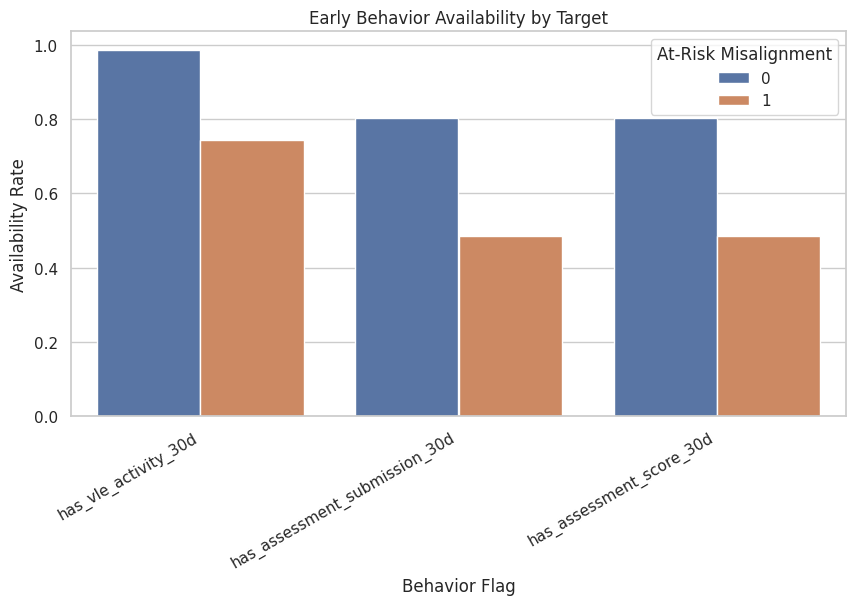

In [12]:
behavior_plot_data = (
    early_behavior_dataset
    .groupby("at_risk_misalignment")[behavior_flag_columns]
    .mean()
    .reset_index()
    .melt(
        id_vars="at_risk_misalignment",
        value_vars=behavior_flag_columns,
        var_name="behavior_flag",
        value_name="availability_rate"
    )
)

plt.figure(figsize=(10, 5))

sns.barplot(
    data=behavior_plot_data,
    x="behavior_flag",
    y="availability_rate",
    hue="at_risk_misalignment"
)

plt.title("Early Behavior Availability by Target")
plt.xlabel("Behavior Flag")
plt.ylabel("Availability Rate")
plt.xticks(rotation=30, ha="right")
plt.legend(title="At-Risk Misalignment")

plt.show()

In [13]:
vle_feature_columns = [
    "total_clicks_30d",
    "active_days_30d",
    "avg_clicks_per_active_day_30d",
    "max_clicks_single_day_30d",
    "std_clicks_active_day_30d",
    "activity_span_30d",
    "days_since_last_activity_30d"
]

assessment_feature_columns = [
    "submitted_assessments_30d",
    "scored_assessments_30d",
    "avg_score_30d",
    "min_score_30d",
    "max_score_30d",
    "total_assessment_weight_30d",
    "late_submission_count_30d",
    "avg_days_late_30d",
    "max_days_late_30d",
    "banked_submissions_30d"
]

behavior_feature_columns = vle_feature_columns + assessment_feature_columns

print("Number of behavior features:", len(behavior_feature_columns))
print(behavior_feature_columns)

Number of behavior features: 17
['total_clicks_30d', 'active_days_30d', 'avg_clicks_per_active_day_30d', 'max_clicks_single_day_30d', 'std_clicks_active_day_30d', 'activity_span_30d', 'days_since_last_activity_30d', 'submitted_assessments_30d', 'scored_assessments_30d', 'avg_score_30d', 'min_score_30d', 'max_score_30d', 'total_assessment_weight_30d', 'late_submission_count_30d', 'avg_days_late_30d', 'max_days_late_30d', 'banked_submissions_30d']


In [14]:
behavior_means_by_target = (
    early_behavior_dataset
    .groupby("at_risk_misalignment")[behavior_feature_columns]
    .mean()
    .T
)

behavior_means_by_target.columns = [
    "stable_0",
    "at_risk_1"
]

behavior_means_by_target["difference_at_risk_minus_stable"] = (
    behavior_means_by_target["at_risk_1"]
    - behavior_means_by_target["stable_0"]
)

behavior_means_by_target

,stable_0,at_risk_1,difference_at_risk_minus_stable
total_clicks_30d,368.644394,160.403359,-208.241035
active_days_30d,13.799610,6.937529,-6.862081
avg_clicks_per_active_day_30d,23.140284,15.048859,-8.091425
max_clicks_single_day_30d,79.281443,45.374245,-33.907198
std_clicks_active_day_30d,22.599668,14.258697,-8.340971
activity_span_30d,25.627559,15.673117,-9.954442
days_since_last_activity_30d,2.809945,12.425093,9.615148
submitted_assessments_30d,0.975431,0.549628,-0.425803
scored_assessments_30d,0.975431,0.548640,-0.426790
avg_score_30d,62.293912,31.580689,-30.713223


In [15]:
behavior_mean_differences = behavior_means_by_target.copy()

behavior_mean_differences["absolute_difference"] = (
    behavior_mean_differences["difference_at_risk_minus_stable"].abs()
)

behavior_mean_differences = behavior_mean_differences.sort_values(
    by="absolute_difference",
    ascending=False
)

behavior_mean_differences

,stable_0,at_risk_1,difference_at_risk_minus_stable,absolute_difference
total_clicks_30d,368.644394,160.403359,-208.241035,208.241035
max_clicks_single_day_30d,79.281443,45.374245,-33.907198,33.907198
max_score_30d,63.066103,31.974837,-31.091266,31.091266
avg_score_30d,62.293912,31.580689,-30.713223,30.713223
min_score_30d,61.478843,31.180846,-30.297997,30.297997
activity_span_30d,25.627559,15.673117,-9.954442,9.954442
days_since_last_activity_30d,2.809945,12.425093,9.615148,9.615148
std_clicks_active_day_30d,22.599668,14.258697,-8.340971,8.340971
avg_clicks_per_active_day_30d,23.140284,15.048859,-8.091425,8.091425
active_days_30d,13.799610,6.937529,-6.862081,6.862081


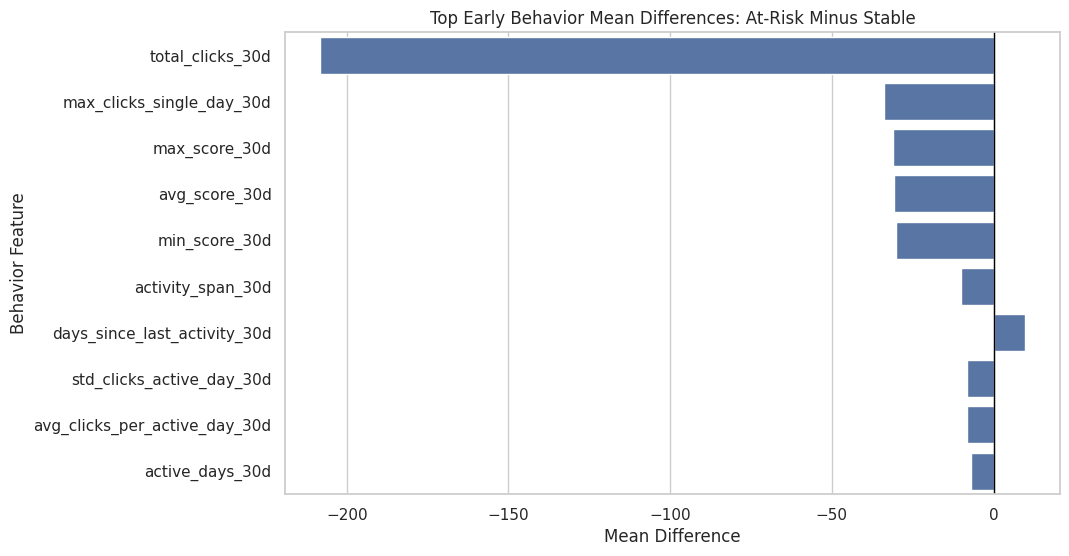

In [16]:
top_behavior_differences = behavior_mean_differences.head(10).copy()

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_behavior_differences.reset_index(),
    x="difference_at_risk_minus_stable",
    y="index",
    orient="h"
)

plt.axvline(0, color="black", linewidth=1)

plt.title("Top Early Behavior Mean Differences: At-Risk Minus Stable")
plt.xlabel("Mean Difference")
plt.ylabel("Behavior Feature")

plt.show()

In [17]:
feature_labels = {
    "total_clicks_30d": "Total Clicks",
    "active_days_30d": "Active Days",
    "activity_span_30d": "Activity Span",
    "days_since_last_activity_30d": "Days Since Last Activity",
    "avg_score_30d": "Average Score",
    "submitted_assessments_30d": "Submitted Assessments",
    "has_vle_activity_30d": "Has VLE Activity",
    "has_assessment_submission_30d": "Has Assessment Submission"
}

print("Feature labels created successfully.")

Feature labels created successfully.


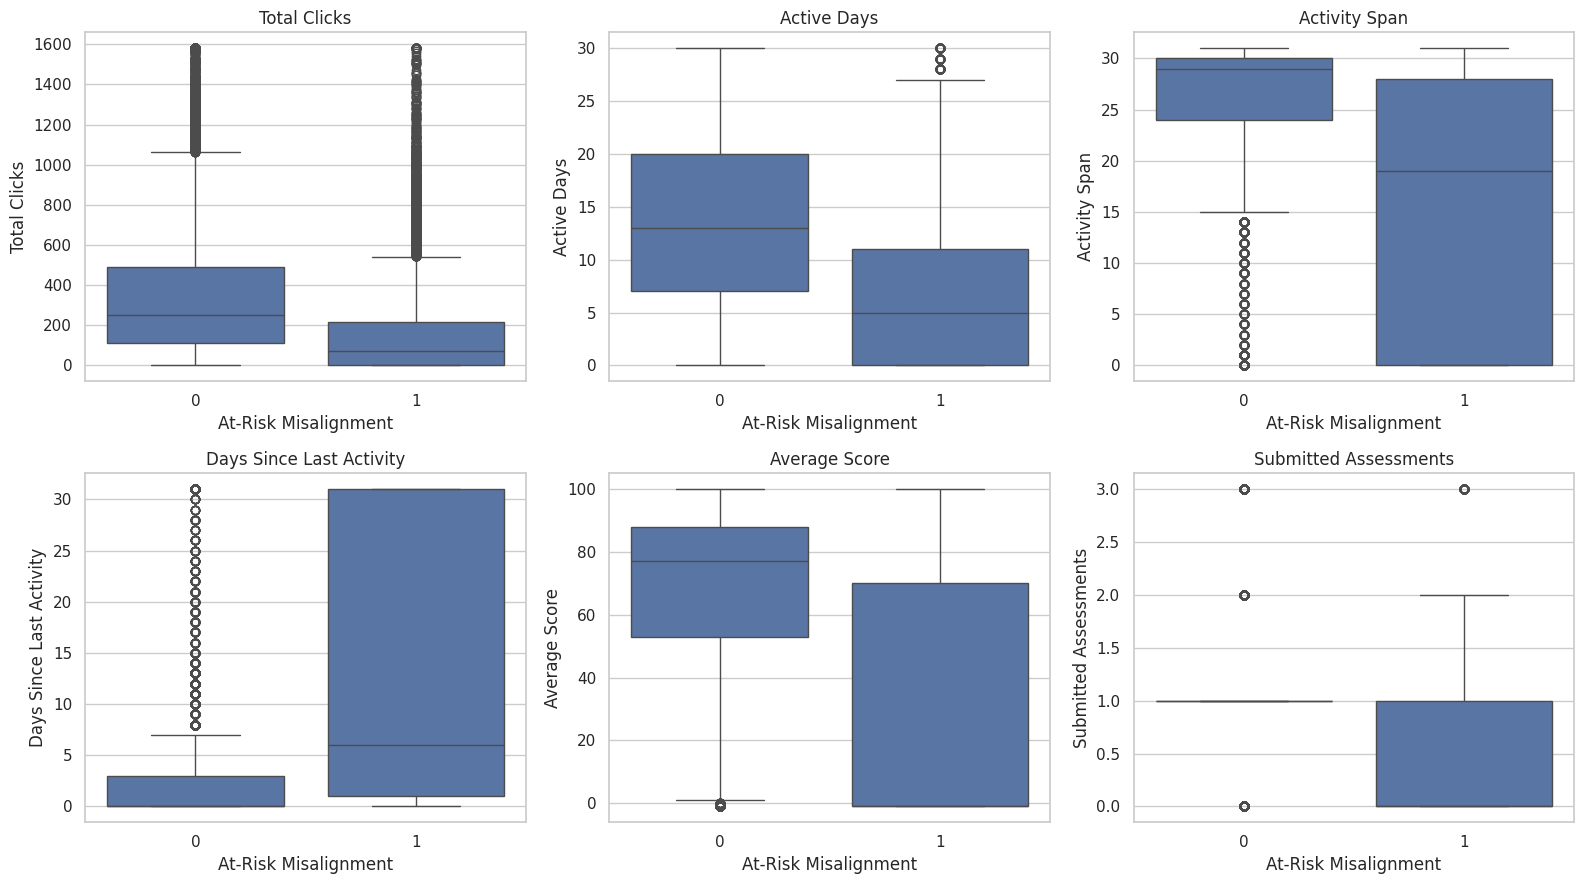

In [18]:
key_numerical_features = [
    "total_clicks_30d",
    "active_days_30d",
    "activity_span_30d",
    "days_since_last_activity_30d",
    "avg_score_30d",
    "submitted_assessments_30d"
]

plot_data = early_behavior_dataset.copy()

for column in key_numerical_features:
    upper_limit = plot_data[column].quantile(0.99)
    plot_data[column] = plot_data[column].clip(upper=upper_limit)

# Create boxplots.
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for index, column in enumerate(key_numerical_features):
    sns.boxplot(
        data=plot_data,
        x="at_risk_misalignment",
        y=column,
        ax=axes[index]
    )
    
    axes[index].set_title(feature_labels.get(column, column))
    axes[index].set_xlabel("At-Risk Misalignment")
    axes[index].set_ylabel(feature_labels.get(column, column))

plt.tight_layout()
plt.show()

In [19]:
eda_binned_dataset = early_behavior_dataset.copy()

eda_binned_dataset["active_days_bin"] = pd.cut(
    eda_binned_dataset["active_days_30d"],
    bins=[-1, 0, 5, 10, 20, 31],
    labels=["0 days", "1-5 days", "6-10 days", "11-20 days", "21-31 days"]
)

eda_binned_dataset["total_clicks_bin"] = pd.cut(
    eda_binned_dataset["total_clicks_30d"],
    bins=[-1, 0, 50, 150, 400, np.inf],
    labels=["0 clicks", "1-50 clicks", "51-150 clicks", "151-400 clicks", "400+ clicks"]
)

eda_binned_dataset["days_since_last_activity_bin"] = pd.cut(
    eda_binned_dataset["days_since_last_activity_30d"],
    bins=[-1, 0, 3, 7, 15, 31],
    labels=["0 days", "1-3 days", "4-7 days", "8-15 days", "16-31 days"]
)

print("Behavior bins created successfully.")

eda_binned_dataset[
    [
        "active_days_30d",
        "active_days_bin",
        "total_clicks_30d",
        "total_clicks_bin",
        "days_since_last_activity_30d",
        "days_since_last_activity_bin"
    ]
].head()

Behavior bins created successfully.


,active_days_30d,active_days_bin,total_clicks_30d,total_clicks_bin,days_since_last_activity_30d,days_since_last_activity_bin
0,9.0,6-10 days,326.0,151-400 clicks,0.0,0 days
1,12.0,11-20 days,403.0,400+ clicks,2.0,1-3 days
2,6.0,6-10 days,179.0,151-400 clicks,18.0,16-31 days
3,19.0,11-20 days,371.0,151-400 clicks,0.0,0 days
4,16.0,11-20 days,272.0,151-400 clicks,4.0,4-7 days


In [20]:
risk_by_active_days = (
    eda_binned_dataset
    .groupby("active_days_bin", observed=True)
    .agg(
        student_count=("at_risk_misalignment", "count"),
        at_risk_rate=("at_risk_misalignment", "mean")
    )
    .reset_index()
)

risk_by_active_days["at_risk_rate"] = (
    risk_by_active_days["at_risk_rate"] * 100
).round(2)

risk_by_active_days

,active_days_bin,student_count,at_risk_rate
0,0 days,4622,95.50
1,1-5 days,6881,66.30
2,6-10 days,7087,51.12
3,11-20 days,9564,37.30
4,21-31 days,4439,23.47


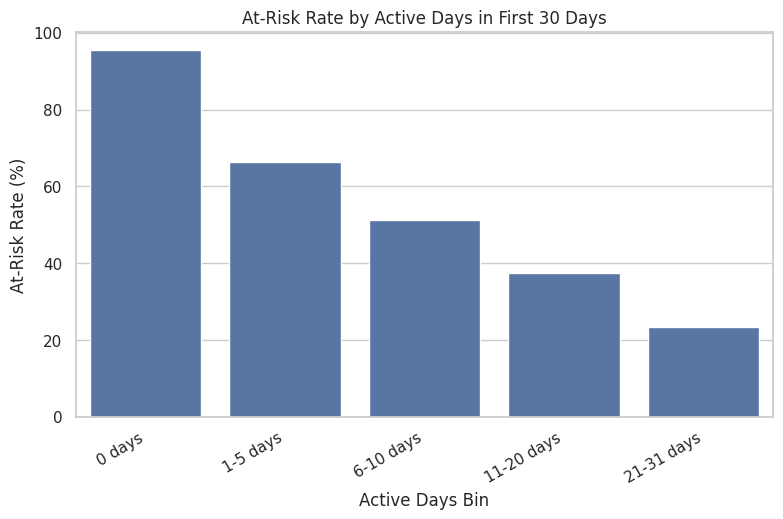

In [21]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=risk_by_active_days,
    x="active_days_bin",
    y="at_risk_rate"
)

plt.title("At-Risk Rate by Active Days in First 30 Days")
plt.xlabel("Active Days Bin")
plt.ylabel("At-Risk Rate (%)")
plt.xticks(rotation=30, ha="right")

plt.show()

In [22]:
risk_by_recency = (
    eda_binned_dataset
    .groupby("days_since_last_activity_bin", observed=True)
    .agg(
        student_count=("at_risk_misalignment", "count"),
        at_risk_rate=("at_risk_misalignment", "mean")
    )
    .reset_index()
)

risk_by_recency["at_risk_rate"] = (
    risk_by_recency["at_risk_rate"] * 100
).round(2)

risk_by_recency

,days_since_last_activity_bin,student_count,at_risk_rate
0,0 days,12150,33.66
1,1-3 days,6293,41.90
2,4-7 days,4475,54.84
3,8-15 days,3025,65.72
4,16-31 days,6650,90.81


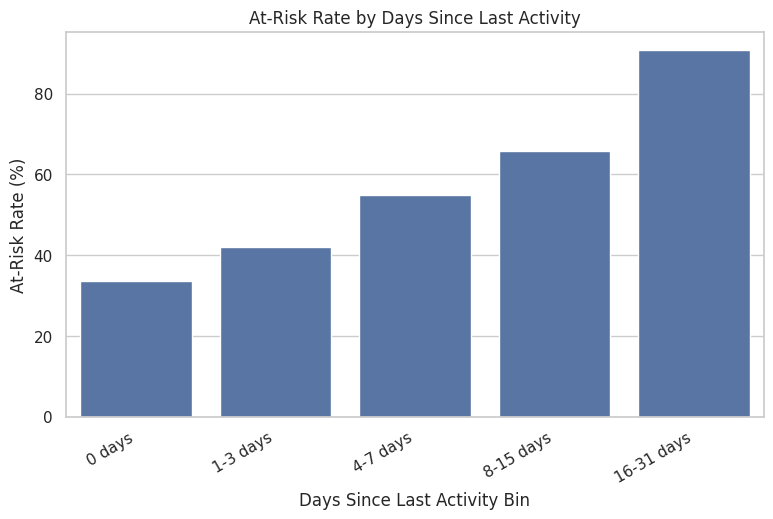

In [23]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=risk_by_recency,
    x="days_since_last_activity_bin",
    y="at_risk_rate"
)

plt.title("At-Risk Rate by Days Since Last Activity")
plt.xlabel("Days Since Last Activity Bin")
plt.ylabel("At-Risk Rate (%)")
plt.xticks(rotation=30, ha="right")

plt.show()

In [24]:
risk_by_assessment_submission = (
    early_behavior_dataset
    .groupby("has_assessment_submission_30d")
    .agg(
        student_count=("at_risk_misalignment", "count"),
        at_risk_rate=("at_risk_misalignment", "mean")
    )
    .reset_index()
)

risk_by_assessment_submission["at_risk_rate"] = (
    risk_by_assessment_submission["at_risk_rate"] * 100
).round(2)

risk_by_assessment_submission

,has_assessment_submission_30d,student_count,at_risk_rate
0,0,11873,74.41
1,1,20720,40.41


In [25]:
EDA_OUTPUTS = DATA_PROCESSED / "eda_outputs"

EDA_OUTPUTS.mkdir(parents=True, exist_ok=True)

print("EDA output folder:")
print(EDA_OUTPUTS)

EDA output folder:
../data/processed/eda_outputs


In [26]:
target_summary.to_csv(
    EDA_OUTPUTS / "target_summary.csv"
)

behavior_availability_by_target.to_csv(
    EDA_OUTPUTS / "behavior_availability_by_target.csv"
)

behavior_means_by_target.to_csv(
    EDA_OUTPUTS / "behavior_means_by_target.csv"
)

behavior_mean_differences.to_csv(
    EDA_OUTPUTS / "behavior_mean_differences.csv"
)

risk_by_active_days.to_csv(
    EDA_OUTPUTS / "risk_by_active_days.csv",
    index=False
)

risk_by_recency.to_csv(
    EDA_OUTPUTS / "risk_by_recency.csv",
    index=False
)

risk_by_assessment_submission.to_csv(
    EDA_OUTPUTS / "risk_by_assessment_submission.csv",
    index=False
)

print("EDA summary tables saved successfully.")

EDA summary tables saved successfully.


Notebook 03 Summary

This notebook explored the relationship between early behavior signals and `at_risk_misalignment`.

Main findings:

1. At-risk students showed lower early VLE activity.
2. At-risk students had fewer active days during the first 30 days.
3. At-risk students had a longer gap since last recorded activity.
4. At-risk students were less likely to submit assessments during the early window.
5. Assessment score features showed strong differences, but they must be interpreted carefully because missing scores were encoded as `-1`.

Interpretation:

Early disengagement appears to be visible before the final course result.

The strongest early behavioral signals are related to:

- activity intensity
- activity consistency
- recency of last activity
- assessment participation
- score availability

Saved outputs:

`data/processed/eda_outputs/`

Next notebook:

`04_modeling_at_risk_misalignment.ipynb`

The next notebook will train baseline models to predict `at_risk_misalignment` using early behavior features.